<a href="https://colab.research.google.com/github/alamnahk/Computational-Research-Projects/blob/main/Machine_Learning_Classification_of_HCC_Biomarkers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'GEOparse', 'shap', '-q'], check=True)

CompletedProcess(args=['pip', 'install', 'GEOparse', 'shap', '-q'], returncode=0)

In [2]:
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings
import json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from scipy import stats

print("All libraries imported successfully.")


All libraries imported successfully.


In [3]:
print("\n" + "="*60)
print("LOADING GSE14520 -- DISCOVERY COHORT")
print("="*60)

gse = GEOparse.get_GEO(geo="GSE14520", destdir="./")

# Extract expression matrix
pivot_df = gse.pivot_samples('VALUE')
print(f"Expression matrix: {pivot_df.shape[0]} probes x {pivot_df.shape[1]} samples")

# Get platform annotation
platform_key = list(gse.gpls.keys())[0]
gpl = gse.gpls[platform_key]

# Selected probes for four genes (Affymetrix GPL571)
selected_probes = {
    'TP53':   '201746_at',
    'BAX':    '208478_s_at',
    'MT1H':   '206461_x_at',
    'TM4SF5': '206242_at'
}

# Extract four-gene expression
gene_expr = pd.DataFrame()
for gene, probe in selected_probes.items():
    gene_expr[gene] = pivot_df.loc[probe]

# Label samples: 0 = non-tumor, 1 = tumor
labels = []
for gsm_name, gsm in gse.gsms.items():
    characteristics = gsm.metadata.get('characteristics_ch1', [])
    tissue = ''
    for c in characteristics:
        if 'tissue:' in c.lower():
            tissue = c.lower()
            break
    if 'non-tumor' in tissue:
        labels.append(0)
    else:
        labels.append(1)

gene_expr['Label'] = labels

print(f"Total samples: {len(labels)}")
print(f"Tumor samples (1): {labels.count(1)}")
print(f"Non-tumor samples (0): {labels.count(0)}")
print("\nBasic statistics:")
print(gene_expr[['TP53', 'BAX', 'MT1H', 'TM4SF5']].describe())




31-May-2026 03:03:46 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
31-May-2026 03:03:46 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE14nnn/GSE14520/soft/GSE14520_family.soft.gz to ./GSE14520_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE14nnn/GSE14520/soft/GSE14520_family.soft.gz to ./GSE14520_family.soft.gz



LOADING GSE14520 -- DISCOVERY COHORT


100%|██████████| 63.9M/63.9M [00:00<00:00, 145MB/s]
31-May-2026 03:03:47 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
31-May-2026 03:03:47 DEBUG downloader - Moving /tmp/tmp7vo1przh to /content/GSE14520_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp7vo1przh to /content/GSE14520_family.soft.gz
31-May-2026 03:03:47 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE14nnn/GSE14520/soft/GSE14520_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE14nnn/GSE14520/soft/GSE14520_family.soft.gz
31-May-2026 03:03:47 INFO GEOparse - Parsing ./GSE14520_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE14520_family.soft.gz: 
31-May-2026 03:03:47 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
31-May-2026 03:03:47 DEBUG GEOparse - SERIES: GSE14520
DEBUG:GEOparse:SERIES: GSE14520
31-May-2026 03:03:47 DEBUG GEOparse - PLATFORM: GPL571
DEBUG:GEOparse:PLATFORM: GPL571
31-May-2026

Expression matrix: 22268 probes x 488 samples
Total samples: 488
Tumor samples (1): 249
Non-tumor samples (0): 239

Basic statistics:
             TP53         BAX        MT1H      TM4SF5
count  488.000000  488.000000  488.000000  488.000000
mean     4.718328    4.303746   10.080043    7.809201
std      0.729483    0.514539    2.033508    0.961531
min      3.131000    3.488000    5.101000    3.826000
25%      4.242250    3.962750    8.612250    7.352750
50%      4.593500    4.202500   10.913500    7.751000
75%      5.107750    4.493500   11.740250    8.308500
max      7.561000    7.114000   13.310000   10.778000


In [4]:
print("\n" + "="*60)
print("DIFFERENTIAL EXPRESSION ANALYSIS (T-TESTS)")
print("="*60)

for gene in ['TP53', 'BAX', 'MT1H', 'TM4SF5']:
    non_tumor = gene_expr[gene_expr['Label']==0][gene]
    tumor = gene_expr[gene_expr['Label']==1][gene]
    t_stat, p_val = stats.ttest_ind(non_tumor, tumor)
    print(f"\n{gene}:")
    print(f"  Non-Tumor: mean={non_tumor.mean():.3f}, std={non_tumor.std():.3f}")
    print(f"  Tumor:     mean={tumor.mean():.3f}, std={tumor.std():.3f}")
    print(f"  T-statistic: {t_stat:.3f}")
    print(f"  P-value: {p_val:.3e}")



DIFFERENTIAL EXPRESSION ANALYSIS (T-TESTS)

TP53:
  Non-Tumor: mean=4.505, std=0.389
  Tumor:     mean=4.923, std=0.902
  T-statistic: -6.600
  P-value: 1.081e-10

BAX:
  Non-Tumor: mean=4.137, std=0.361
  Tumor:     mean=4.464, std=0.585
  T-statistic: -7.380
  P-value: 6.892e-13

MT1H:
  Non-Tumor: mean=11.641, std=0.543
  Tumor:     mean=8.582, std=1.799
  T-statistic: 25.213
  P-value: 2.598e-90

TM4SF5:
  Non-Tumor: mean=7.623, std=0.610
  Tumor:     mean=7.988, std=1.180
  T-statistic: -4.273
  P-value: 2.326e-05


In [5]:
X = gene_expr[['TP53', 'BAX', 'MT1H', 'TM4SF5']]
y = gene_expr['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)



In [6]:
print("\n" + "="*60)
print("ALL 7 MODELS -- GSE14520 PERFORMANCE")
print("="*60)

models = {
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression':LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes':        GaussianNB(),
    'SVM':                SVC(kernel='rbf', random_state=42, probability=True),
    'KNN':                KNeighborsClassifier(n_neighbors=5),
    'Neural Network':     MLPClassifier(hidden_layer_sizes=(64, 32),
                                        activation='relu',
                                        max_iter=1000,
                                        random_state=42)
}

results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=cv, scoring='accuracy')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'model':  model,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred
    }

    print(f"\n{name}:")
    print(f"  CV Accuracy:    {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(f"  Test Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"  Precision:      {results[name]['precision']:.4f}")
    print(f"  Recall:         {results[name]['recall']:.4f}")
    print(f"  F1 Score:       {results[name]['f1']:.4f}")

print(f"\nTumor: {labels.count(1)} | Non-tumor: {labels.count(0)}")



ALL 7 MODELS -- GSE14520 PERFORMANCE

Random Forest:
  CV Accuracy:    0.9128 +/- 0.0489
  Test Accuracy:  0.9184
  Precision:      0.9200
  Recall:         0.9200
  F1 Score:       0.9200

Gradient Boosting:
  CV Accuracy:    0.9051 +/- 0.0459
  Test Accuracy:  0.9286
  Precision:      0.9388
  Recall:         0.9200
  F1 Score:       0.9293

Logistic Regression:
  CV Accuracy:    0.9128 +/- 0.0528
  Test Accuracy:  0.9286
  Precision:      0.9388
  Recall:         0.9200
  F1 Score:       0.9293

Naive Bayes:
  CV Accuracy:    0.9205 +/- 0.0567
  Test Accuracy:  0.9592
  Precision:      0.9600
  Recall:         0.9600
  F1 Score:       0.9600

SVM:
  CV Accuracy:    0.9282 +/- 0.0497
  Test Accuracy:  0.9286
  Precision:      0.9574
  Recall:         0.9000
  F1 Score:       0.9278

KNN:
  CV Accuracy:    0.9103 +/- 0.0609
  Test Accuracy:  0.9082
  Precision:      0.9556
  Recall:         0.8600
  F1 Score:       0.9053

Neural Network:
  CV Accuracy:    0.8846 +/- 0.0401
  Test Ac

In [7]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE (Random Forest)")
print("="*60)

rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
gene_names = ['TP53', 'BAX', 'MT1H', 'TM4SF5']
sorted_idx = np.argsort(importances)[::-1]

for i in sorted_idx:
    print(f"  {gene_names[i]}: {importances[i]*100:.2f}%")




FEATURE IMPORTANCE (Random Forest)
  MT1H: 65.58%
  TP53: 14.10%
  TM4SF5: 10.75%
  BAX: 9.57%


In [10]:
print("\n" + "="*60)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("="*60)

lr_model = results['Logistic Regression']['model']
coef_df = pd.DataFrame({
    'Feature': gene_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient')
print(coef_df.to_string(index=False))



LOGISTIC REGRESSION COEFFICIENTS
Feature  Coefficient
   MT1H    -3.546228
   TP53    -0.007296
 TM4SF5     0.167133
    BAX     0.809683


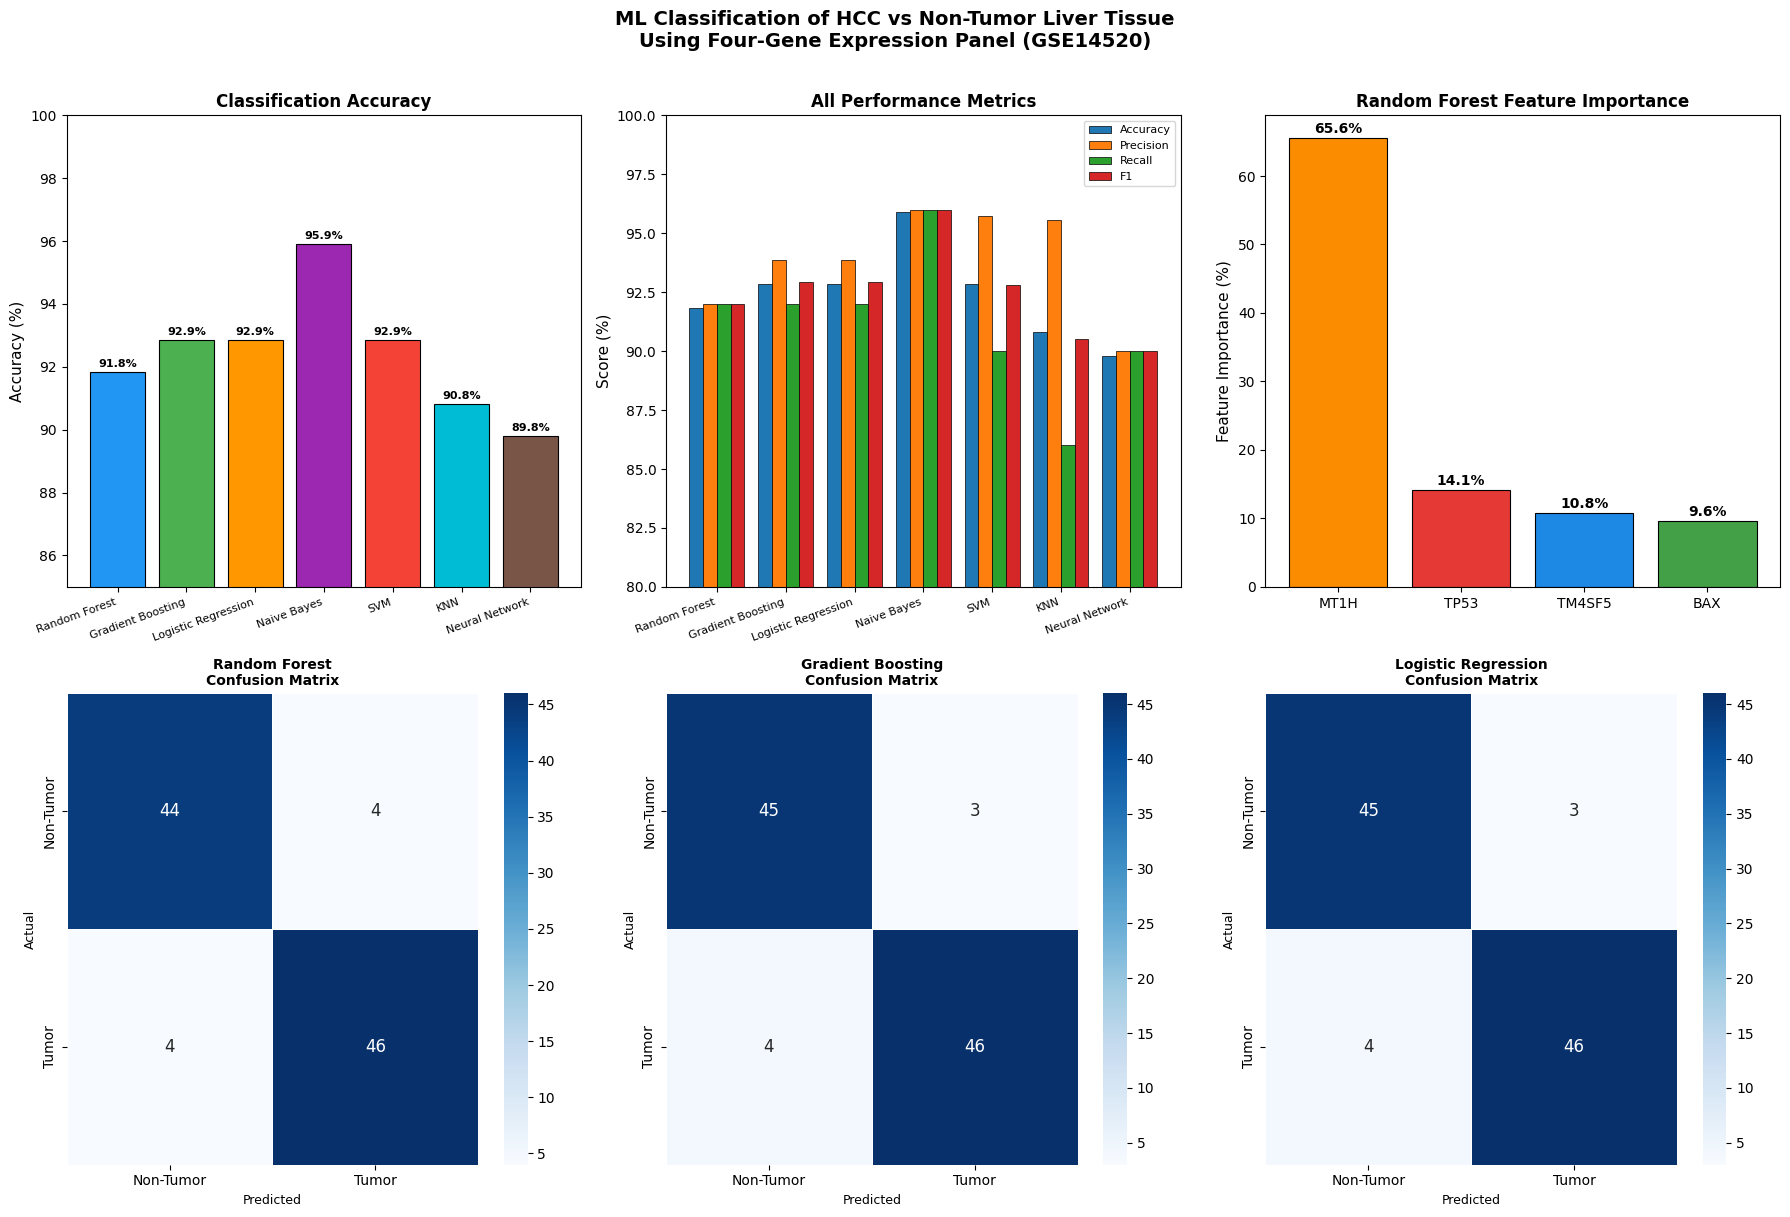

Figure saved: ML_Results_Combined.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ML Classification of HCC vs Non-Tumor Liver Tissue\nUsing Four-Gene Expression Panel (GSE14520)',
             fontsize=14, fontweight='bold', y=1.01)

# Accuracy bar chart
ax1 = axes[0, 0]
names = list(results.keys())
accuracies = [results[n]['accuracy']*100 for n in names]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4', '#795548']
bars = ax1.bar(names, accuracies, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_ylim(85, 100)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Classification Accuracy', fontsize=12, fontweight='bold')
ax1.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# All metrics
ax2 = axes[0, 1]
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(names))
width = 0.2
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = [results[n][metric]*100 for n in names]
    ax2.bar(x + i*width, values, width, label=label, edgecolor='black', linewidth=0.5)
ax2.set_ylim(80, 100)
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.set_title('All Performance Metrics', fontsize=12, fontweight='bold')
ax2.set_xticks(x + width*1.5)
ax2.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax2.legend(fontsize=8)

# Feature importance
ax3 = axes[0, 2]
colors_fi = ['#E53935', '#43A047', '#FB8C00', '#1E88E5']
bars_fi = ax3.bar([gene_names[i] for i in sorted_idx],
                   [importances[i]*100 for i in sorted_idx],
                   color=[colors_fi[i] for i in sorted_idx],
                   edgecolor='black', linewidth=0.8)
ax3.set_ylabel('Feature Importance (%)', fontsize=11)
ax3.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
for bar, imp in zip(bars_fi, [importances[i]*100 for i in sorted_idx]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{imp:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Confusion matrices for first 3 models
for idx, (name, ax) in enumerate(zip(list(results.keys())[:3], [axes[1,0], axes[1,1], axes[1,2]])):
    cm = results[name]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Tumor', 'Tumor'],
                yticklabels=['Non-Tumor', 'Tumor'],
                linewidths=0.5, annot_kws={'size': 12})
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=10, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)

plt.tight_layout()
plt.savefig('ML_Results_Combined.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: ML_Results_Combined.png")



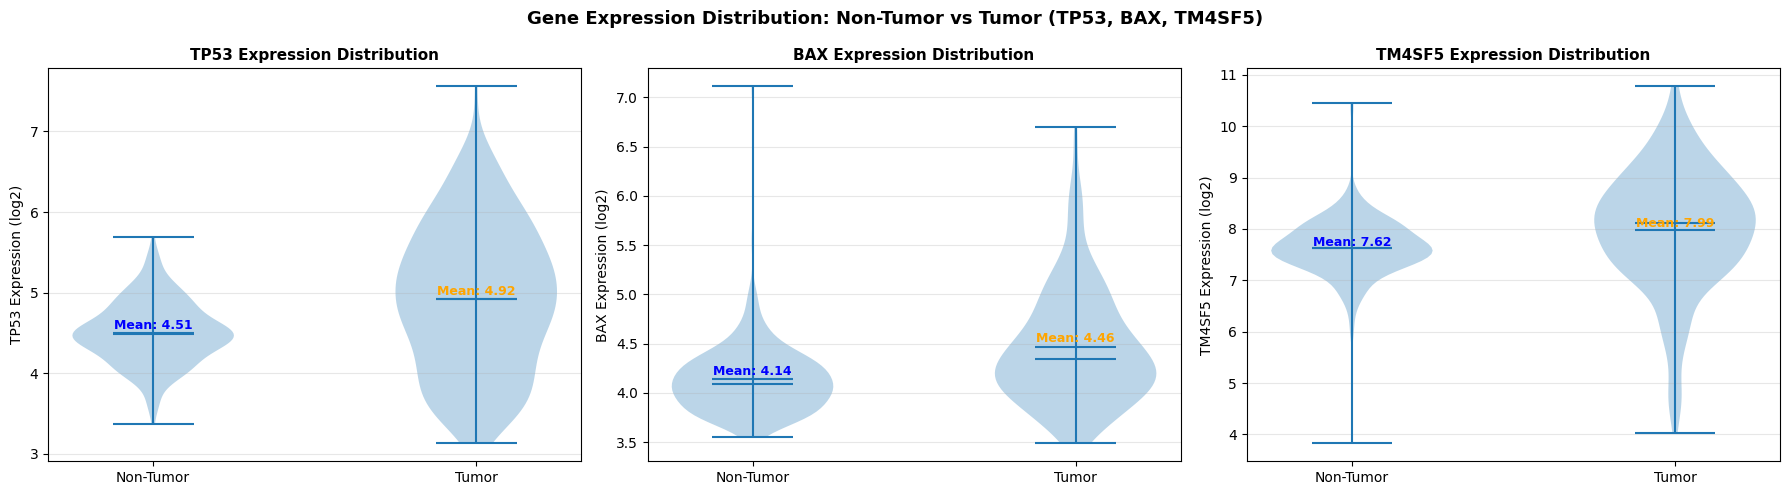

Figure saved: Gene_Expression_Violins.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gene Expression Distribution: Non-Tumor vs Tumor (TP53, BAX, TM4SF5)',
             fontsize=13, fontweight='bold')

for idx, gene in enumerate(['TP53', 'BAX', 'TM4SF5']):
    ax = axes[idx]
    non_tumor_vals = gene_expr[gene_expr['Label']==0][gene]
    tumor_vals = gene_expr[gene_expr['Label']==1][gene]
    ax.violinplot([non_tumor_vals, tumor_vals], positions=[1, 2],
                  showmeans=True, showmedians=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Non-Tumor', 'Tumor'], fontsize=10)
    ax.set_ylabel(f'{gene} Expression (log2)', fontsize=10)
    ax.set_title(f'{gene} Expression Distribution', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.text(1, non_tumor_vals.mean() + 0.05,
            f'Mean: {non_tumor_vals.mean():.2f}',
            ha='center', fontsize=9, color='blue', fontweight='bold')
    ax.text(2, tumor_vals.mean() + 0.05,
            f'Mean: {tumor_vals.mean():.2f}',
            ha='center', fontsize=9, color='orange', fontweight='bold')

plt.tight_layout()
plt.savefig('Gene_Expression_Violins.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: Gene_Expression_Violins.png")



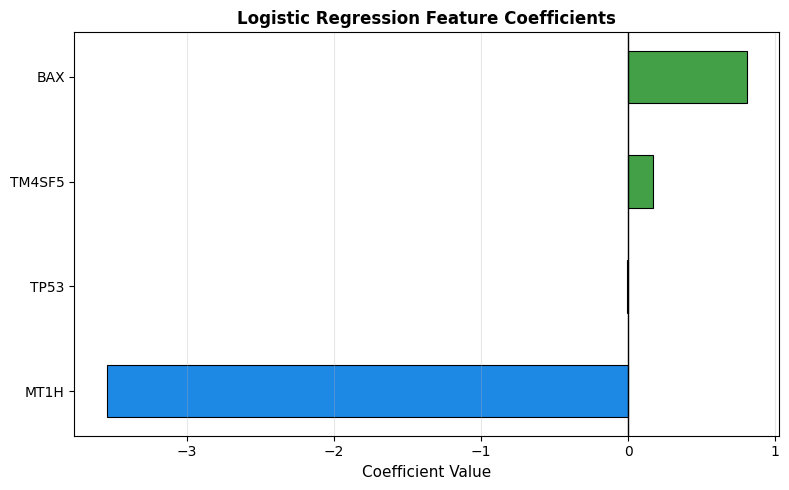

Figure saved: Logistic_Regression_Coefficients.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
coef_sorted = coef_df.sort_values('Coefficient')
colors_lr = ['#1E88E5' if c < 0 else '#43A047' for c in coef_sorted['Coefficient']]
bars = ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'],
               color=colors_lr, edgecolor='black', linewidth=0.8, height=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.set_title('Logistic Regression Feature Coefficients', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Logistic_Regression_Coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: Logistic_Regression_Coefficients.png")



Running SHAP analysis...


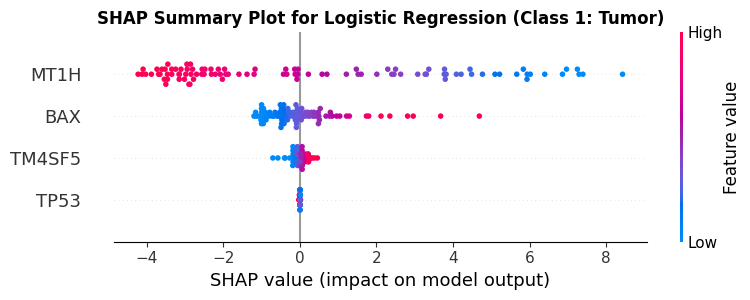

Figure saved: SHAP_Summary_Plot.png


<Figure size 800x600 with 0 Axes>

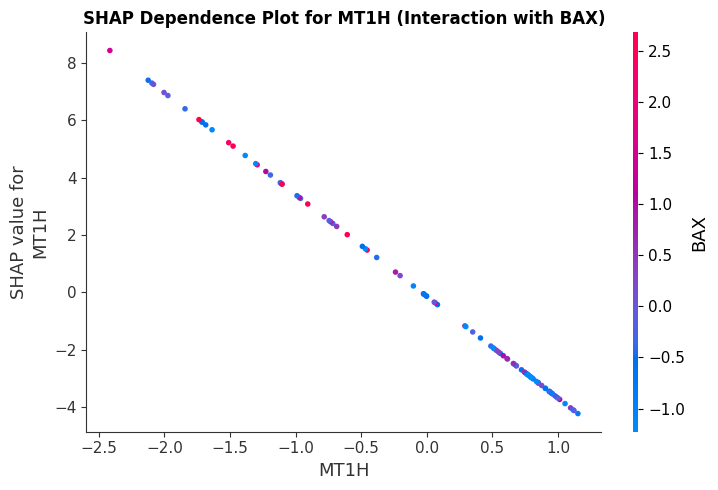

Figure saved: SHAP_Dependence_MT1H.png


In [14]:
print("\nRunning SHAP analysis...")

lr_model_shap = results['Logistic Regression']['model']
explainer = shap.LinearExplainer(lr_model_shap, X_train_scaled,
                                  feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=gene_names,
                  plot_type="dot", show=False)
plt.title('SHAP Summary Plot for Logistic Regression (Class 1: Tumor)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('SHAP_Summary_Plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: SHAP_Summary_Plot.png")

# SHAP dependence plot for MT1H
plt.figure(figsize=(8, 6))
mt1h_idx = gene_names.index('MT1H')
bax_idx = gene_names.index('BAX')
shap.dependence_plot(mt1h_idx, shap_values, X_test_scaled,
                     feature_names=gene_names,
                     interaction_index=bax_idx, show=False)
plt.title('SHAP Dependence Plot for MT1H (Interaction with BAX)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('SHAP_Dependence_MT1H.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: SHAP_Dependence_MT1H.png")


In [15]:
print("\n" + "="*60)
print("LOADING GSE36376 -- VALIDATION COHORT")
print("="*60)

gse2 = GEOparse.get_GEO(geo="GSE36376", destdir="./")
pivot_df2 = gse2.pivot_samples('VALUE')
print(f"Expression matrix: {pivot_df2.shape[0]} probes x {pivot_df2.shape[1]} samples")

# Selected probes for four genes (Illumina GPL10558)
selected_probes2 = {
    'TP53':   'ILMN_1779356',
    'BAX':    'ILMN_1683300',
    'MT1H':   'ILMN_1683923',
    'TM4SF5': 'ILMN_2167808'
}

gene_expr2 = pd.DataFrame()
for gene, probe in selected_probes2.items():
    gene_expr2[gene] = pivot_df2.loc[probe]

# Label samples
labels2 = []
for gsm_name, gsm in gse2.gsms.items():
    characteristics = gsm.metadata.get('characteristics_ch1', [])
    tissue = ''
    for c in characteristics:
        if 'tissue:' in c.lower():
            tissue = c.lower()
            break
    if 'non-tumor' in tissue or 'adjacent' in tissue:
        labels2.append(0)
    else:
        labels2.append(1)

gene_expr2['Label'] = labels2

print(f"Total samples: {len(labels2)}")
print(f"Tumor samples (1): {labels2.count(1)}")
print(f"Non-tumor samples (0): {labels2.count(0)}")


31-May-2026 03:09:37 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
31-May-2026 03:09:37 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE36nnn/GSE36376/soft/GSE36376_family.soft.gz to ./GSE36376_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE36nnn/GSE36376/soft/GSE36376_family.soft.gz to ./GSE36376_family.soft.gz



LOADING GSE36376 -- VALIDATION COHORT


100%|██████████| 247M/247M [00:02<00:00, 124MB/s]
31-May-2026 03:09:39 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
31-May-2026 03:09:39 DEBUG downloader - Moving /tmp/tmp5ewsdwht to /content/GSE36376_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp5ewsdwht to /content/GSE36376_family.soft.gz
31-May-2026 03:09:42 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE36nnn/GSE36376/soft/GSE36376_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE36nnn/GSE36376/soft/GSE36376_family.soft.gz
31-May-2026 03:09:42 INFO GEOparse - Parsing ./GSE36376_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE36376_family.soft.gz: 
31-May-2026 03:09:42 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
31-May-2026 03:09:42 DEBUG GEOparse - SERIES: GSE36376
DEBUG:GEOparse:SERIES: GSE36376
31-May-2026 03:09:42 DEBUG GEOparse - PLATFORM: GPL10558
DEBUG:GEOparse:PLATFORM: GPL10558
31-May-20

Expression matrix: 47323 probes x 433 samples
Total samples: 433
Tumor samples (1): 240
Non-tumor samples (0): 193


In [16]:
print("\n" + "="*60)
print("ALL 7 MODELS -- GSE36376 PERFORMANCE")
print("="*60)

X2 = gene_expr2[['TP53', 'BAX', 'MT1H', 'TM4SF5']]
y2 = gene_expr2['Label']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

cv2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results2 = {}
models2 = {
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression':LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes':        GaussianNB(),
    'SVM':                SVC(kernel='rbf', random_state=42, probability=True),
    'KNN':                KNeighborsClassifier(n_neighbors=5),
    'Neural Network':     MLPClassifier(hidden_layer_sizes=(64, 32),
                                        activation='relu',
                                        max_iter=1000,
                                        random_state=42)
}

for name, model in models2.items():
    cv_scores = cross_val_score(model, X2_train_scaled, y2_train,
                                cv=cv2, scoring='accuracy')
    model.fit(X2_train_scaled, y2_train)
    y2_pred = model.predict(X2_test_scaled)

    results2[name] = {
        'model':  model,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
        'accuracy':  accuracy_score(y2_test, y2_pred),
        'precision': precision_score(y2_test, y2_pred, zero_division=0),
        'recall':    recall_score(y2_test, y2_pred, zero_division=0),
        'f1':        f1_score(y2_test, y2_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y2_test, y2_pred)
    }

    print(f"\n{name}:")
    print(f"  CV Accuracy:    {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(f"  Test Accuracy:  {results2[name]['accuracy']:.4f}")
    print(f"  Precision:      {results2[name]['precision']:.4f}")
    print(f"  Recall:         {results2[name]['recall']:.4f}")
    print(f"  F1 Score:       {results2[name]['f1']:.4f}")



ALL 7 MODELS -- GSE36376 PERFORMANCE

Random Forest:
  CV Accuracy:    0.8871 +/- 0.0460
  Test Accuracy:  0.9080
  Precision:      0.9348
  Recall:         0.8958
  F1 Score:       0.9149

Gradient Boosting:
  CV Accuracy:    0.8957 +/- 0.0522
  Test Accuracy:  0.8621
  Precision:      0.9091
  Recall:         0.8333
  F1 Score:       0.8696

Logistic Regression:
  CV Accuracy:    0.8434 +/- 0.0786
  Test Accuracy:  0.8276
  Precision:      0.8367
  Recall:         0.8542
  F1 Score:       0.8454

Naive Bayes:
  CV Accuracy:    0.8697 +/- 0.0444
  Test Accuracy:  0.8621
  Precision:      0.9286
  Recall:         0.8125
  F1 Score:       0.8667

SVM:
  CV Accuracy:    0.8841 +/- 0.0567
  Test Accuracy:  0.8966
  Precision:      0.9149
  Recall:         0.8958
  F1 Score:       0.9053

KNN:
  CV Accuracy:    0.8610 +/- 0.0581
  Test Accuracy:  0.8391
  Precision:      0.8696
  Recall:         0.8333
  F1 Score:       0.8511

Neural Network:
  CV Accuracy:    0.8667 +/- 0.0532
  Test Ac

In [17]:
print("\n" + "="*60)
print("CROSS-DATASET VALIDATION")
print("Train: GSE14520 | Test: GSE36376")
print("="*60)

X_full = gene_expr[['TP53', 'BAX', 'MT1H', 'TM4SF5']]
y_full = gene_expr['Label']
X_external = gene_expr2[['TP53', 'BAX', 'MT1H', 'TM4SF5']]
y_external = gene_expr2['Label']

scaler_cross = StandardScaler()
X_full_scaled = scaler_cross.fit_transform(X_full)
X_external_scaled = scaler_cross.transform(X_external)

for name, model_instance in [
    ('Random Forest',      RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('Logistic Regression',LogisticRegression(random_state=42, max_iter=1000)),
    ('Naive Bayes',        GaussianNB()),
    ('SVM',                SVC(kernel='rbf', random_state=42)),
    ('KNN',                KNeighborsClassifier(n_neighbors=5)),
    ('Neural Network',     MLPClassifier(hidden_layer_sizes=(64,32),
                                          activation='relu', max_iter=1000,
                                          random_state=42))
]:
    model_instance.fit(X_full_scaled, y_full)
    y_cross_pred = model_instance.predict(X_external_scaled)
    acc = accuracy_score(y_external, y_cross_pred)
    f1 = f1_score(y_external, y_cross_pred, zero_division=0)
    print(f"{name:25s} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

print("\nNote: Low accuracy expected due to platform batch effects (Affymetrix vs Illumina).")
print("Within-platform classification is robust in both cohorts independently.")




CROSS-DATASET VALIDATION
Train: GSE14520 | Test: GSE36376
Random Forest             | Accuracy: 0.5543 | F1: 0.7132
Gradient Boosting         | Accuracy: 0.5704 | F1: 0.7147
Logistic Regression       | Accuracy: 0.5543 | F1: 0.7132
Naive Bayes               | Accuracy: 0.5543 | F1: 0.7132
SVM                       | Accuracy: 0.5543 | F1: 0.7132
KNN                       | Accuracy: 0.5543 | F1: 0.7132
Neural Network            | Accuracy: 0.5543 | F1: 0.7132

Note: Low accuracy expected due to platform batch effects (Affymetrix vs Illumina).
Within-platform classification is robust in both cohorts independently.


In [18]:
print("\n" + "="*60)
print("SAVING ALL OUTPUT FILES")
print("="*60)

# Save gene expression matrices
gene_expr.to_csv('GSE14520_gene_expression.csv')
gene_expr2.to_csv('GSE36376_gene_expression.csv')

# Save results summaries
summary1 = {}
for name, res in results.items():
    summary1[name] = {
        'cv_accuracy_mean': round(res['cv_mean'], 4),
        'cv_accuracy_std':  round(res['cv_std'], 4),
        'test_accuracy':    round(res['accuracy'], 4),
        'precision':        round(res['precision'], 4),
        'recall':           round(res['recall'], 4),
        'f1_score':         round(res['f1'], 4),
        'confusion_matrix': res['confusion_matrix'].tolist()
    }

summary2 = {}
for name, res in results2.items():
    summary2[name] = {
        'cv_accuracy_mean': round(res['cv_mean'], 4),
        'cv_accuracy_std':  round(res['cv_std'], 4),
        'test_accuracy':    round(res['accuracy'], 4),
        'precision':        round(res['precision'], 4),
        'recall':           round(res['recall'], 4),
        'f1_score':         round(res['f1'], 4),
        'confusion_matrix': res['confusion_matrix'].tolist()
    }

with open('GSE14520_results.json', 'w') as f:
    json.dump(summary1, f, indent=2)

with open('GSE36376_results.json', 'w') as f:
    json.dump(summary2, f, indent=2)

# Save feature importance
fi = {gene_names[i]: round(float(importances[i]), 4) for i in range(4)}
with open('feature_importance.json', 'w') as f:
    json.dump(fi, f, indent=2)

print("\nAll files saved successfully:")
print("  Data files:")
print("    - GSE14520_gene_expression.csv")
print("    - GSE36376_gene_expression.csv")
print("  Results files:")
print("    - GSE14520_results.json")
print("    - GSE36376_results.json")
print("    - feature_importance.json")
print("  Figure files:")
print("    - ML_Results_Combined.png")
print("    - ML_Biomarker_Analysis.png")
print("    - Gene_Expression_Violins.png")
print("    - Logistic_Regression_Coefficients.png")
print("    - SHAP_Summary_Plot.png")
print("    - SHAP_Dependence_MT1H.png")
print("\nDownload all files from the Files panel on the left side of Colab.")
print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)




SAVING ALL OUTPUT FILES

All files saved successfully:
  Data files:
    - GSE14520_gene_expression.csv
    - GSE36376_gene_expression.csv
  Results files:
    - GSE14520_results.json
    - GSE36376_results.json
    - feature_importance.json
  Figure files:
    - ML_Results_Combined.png
    - ML_Biomarker_Analysis.png
    - Gene_Expression_Violins.png
    - Logistic_Regression_Coefficients.png
    - SHAP_Summary_Plot.png
    - SHAP_Dependence_MT1H.png

Download all files from the Files panel on the left side of Colab.

PIPELINE COMPLETE
